In [22]:
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats
import numpy as np

In [ ]:
# Load data files. These were downloaded from the NHANES website (2021-2023 cycle)
demo = pd.read_sas(r"C:\Users\brigi\Downloads\DEMO_L.xpt")
slq = pd.read_sas(r"C:\Users\brigi\Downloads\SLQ_L.xpt")
dpq = pd.read_sas(r"C:\Users\brigi\Downloads\DPQ_L.xpt")

In [3]:
print(demo.shape)
print(slq.shape)
print(dpq.shape)

(11933, 27)
(8501, 7)
(6337, 11)


In [5]:
# Peek at the first few rows of each dataframe
slq.head()

,SEQN,SLQ300,SLQ310,SLD012,SLQ320,SLQ330,SLD013
0,130378.0,b'21:30',b'07:00',9.5,b'00:00',b'09:00',9.0
1,130379.0,b'21:00',b'06:00',9.0,b'21:00',b'06:00',9.0
2,130380.0,b'00:00',b'08:00',8.0,b'00:00',b'09:00',9.0
3,130384.0,b'21:30',b'05:00',7.5,b'23:00',b'07:00',8.0
4,130385.0,b'22:05',b'06:15',8.0,b'22:05',b'06:15',8.0


In [6]:
dpq.head()

,SEQN,DPQ010,DPQ020,DPQ030,DPQ040,DPQ050,DPQ060,DPQ070,DPQ080,DPQ090,DPQ100
0,130378.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,130379.0,5.397605e-79,5.397605e-79,1.000000e+00,5.397605e-79,5.397605e-79,5.397605e-79,5.397605e-79,5.397605e-79,5.397605e-79,5.397605e-79
2,130380.0,5.397605e-79,5.397605e-79,1.000000e+00,1.000000e+00,5.397605e-79,5.397605e-79,5.397605e-79,5.397605e-79,5.397605e-79,5.397605e-79
3,130386.0,5.397605e-79,5.397605e-79,5.397605e-79,5.397605e-79,5.397605e-79,1.000000e+00,5.397605e-79,5.397605e-79,5.397605e-79,5.397605e-79
4,130387.0,5.397605e-79,5.397605e-79,5.397605e-79,5.397605e-79,5.397605e-79,5.397605e-79,5.397605e-79,5.397605e-79,5.397605e-79,NaN


### Initial Observations

**Expected:**
- Both tables have `SEQN` — the join key (equivalent to a primary/foreign key)
- `SLD012` is the sleep duration column: self-reported hours of sleep per night on weekdays/workdays

**Surprises:**
1. The `b'...'` values in SLQ are byte strings — an artifact of how SAS stores text in XPT files. Since we only need `SLD012`, this is not a problem.
2. The DPQ columns contain unusual floating-point values (`5.397605e-79`) where integers are expected. This is how zero is encoded in this XPT file. `1.000000e+00` is just `1.0`, and `NaN` means the question was skipped or not asked.

In [7]:
dpq.dtypes

SEQN      float64
DPQ010    float64
DPQ020    float64
DPQ030    float64
DPQ040    float64
DPQ050    float64
DPQ060    float64
DPQ070    float64
DPQ080    float64
DPQ090    float64
DPQ100    float64
dtype: object

In [ ]:
# Merge the sleep and depression dataframes on the SEQN column (which is the unique identifier for each participant)
# Note: we use an inner join to keep only participants who have data in both dataframes
df = pd.merge(slq, dpq, on='SEQN', how='inner')

In [9]:
print(df.shape)

(6337, 17)


The merged table is the same size as `dpq` (6,337 rows). Every person who completed the depression screener also completed the sleep survey — the depression screener group is a complete subset of the sleep survey group.

Next: clean the data.

In [10]:
df['SLD012'].describe()

count    6272.000000
mean        7.724330
std         1.601201
min         2.000000
25%         7.000000
50%         8.000000
75%         8.500000
max        14.000000
Name: SLD012, dtype: float64

In [11]:
df[['DPQ010', 'DPQ020', 'DPQ030', 'DPQ040', 'DPQ050', 'DPQ060', 'DPQ070', 'DPQ080', 'DPQ090']].describe()   

,DPQ010,DPQ020,DPQ030,DPQ040,DPQ050,DPQ060,DPQ070,DPQ080,DPQ090
count,5.519000e+03,5.518000e+03,5.516000e+03,5.514000e+03,5.513000e+03,5.510000e+03,5.508000e+03,5.508000e+03,5.506000e+03
mean,5.109621e-01,4.786154e-01,7.935098e-01,8.601741e-01,5.042627e-01,4.110708e-01,3.948802e-01,2.165940e-01,8.209226e-02
std,9.466645e-01,8.387239e-01,1.003693e+00,9.651269e-01,8.605773e-01,7.869793e-01,7.675240e-01,6.850770e-01,4.381644e-01
min,5.397605e-79,5.397605e-79,5.397605e-79,5.397605e-79,5.397605e-79,5.397605e-79,5.397605e-79,5.397605e-79,5.397605e-79
25%,5.397605e-79,5.397605e-79,5.397605e-79,5.397605e-79,5.397605e-79,5.397605e-79,5.397605e-79,5.397605e-79,5.397605e-79
50%,5.397605e-79,5.397605e-79,5.397605e-79,1.000000e+00,5.397605e-79,5.397605e-79,5.397605e-79,5.397605e-79,5.397605e-79
75%,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,5.397605e-79,5.397605e-79
max,9.000000e+00,9.000000e+00,9.000000e+00,9.000000e+00,9.000000e+00,9.000000e+00,9.000000e+00,9.000000e+00,9.000000e+00


In [12]:
# Replace 7, 9 with NaN (these are the codes for "Refused" and "Don't know")
dpq_cols = ['DPQ010', 'DPQ020', 'DPQ030', 'DPQ040', 'DPQ050', 'DPQ060', 'DPQ070', 'DPQ080', 'DPQ090']
df[dpq_cols] = df[dpq_cols].replace([7,9], float('nan'))

In [13]:
df[dpq_cols].max()

DPQ010    3.0
DPQ020    3.0
DPQ030    3.0
DPQ040    3.0
DPQ050    3.0
DPQ060    3.0
DPQ070    3.0
DPQ080    3.0
DPQ090    3.0
dtype: float64

In [14]:
# Fix the near-zero float issue by rounding all the DPQ columns to the nearest integer
df[dpq_cols] = df[dpq_cols].round()

In [15]:
df[dpq_cols].min()

DPQ010    0.0
DPQ020    0.0
DPQ030    0.0
DPQ040    0.0
DPQ050    0.0
DPQ060    0.0
DPQ070    0.0
DPQ080    0.0
DPQ090    0.0
dtype: float64

In [16]:
# Now we can drop the incomplete rows
cols_needed = ['SLD012'] + dpq_cols
df = df.dropna(subset=cols_needed)
print(df.shape)

(5401, 17)


After dropping rows with missing values in any key column, we have **5,401 participants** — down from 6,337, a loss of about 15%. This is expected for a population survey where some respondents skip questions or answer "refused" or "don't know."

Next: compute the PHQ-9 score by summing the nine depression questions (DPQ010–DPQ090). Each question is scored 0–3, so the total ranges from 0 to 27. Higher scores indicate more severe depressive symptoms.

In [17]:
# Create a new column that sums the DPQ scores to get a total depression score
df['phq9_score'] = df[dpq_cols].sum(axis=1)
df['phq9_score'].describe()

count    5401.000000
mean        4.106277
std         4.742147
min         0.000000
25%         1.000000
50%         2.000000
75%         6.000000
max        26.000000
Name: phq9_score, dtype: float64

### PHQ-9 Score Distribution

The scores look valid:
- **min=0, max=26** — within the expected 0–27 range
- **median=2** — most people in a general population sample report minimal symptoms, as expected
- **mean=4.1** — pulled upward by the right tail of higher scores
- **75th percentile=6** — 75% of respondents score 6 or below, within the minimal-to-mild range

**Standard PHQ-9 severity cutoffs:**

| Score | Severity |
|-------|----------|
| 0–4 | Minimal |
| 5–9 | Mild |
| 10–14 | Moderate |
| 15–19 | Moderately severe |
| 20–27 | Severe |

### Choosing a Correlation Method

We now have both variables needed for the analysis:
- `SLD012` — sleep duration (hours)
- `phq9_score` — PHQ-9 total score

The most common correlation coefficient is **Pearson**, which measures linear relationships and assumes roughly normally distributed data. Before choosing, let's look at the shape of both variables.

array([[<Axes: title={'center': 'SLD012'}>,
        <Axes: title={'center': 'phq9_score'}>]], dtype=object)

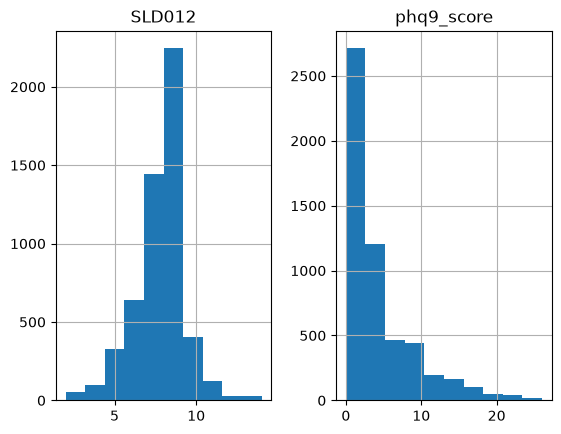

In [20]:
# Plot histograms of sleep duration and PHQ-9 scores
df[['SLD012', 'phq9_score']].hist()

`SLD012` is roughly bell-shaped. `phq9_score` is heavily **right-skewed** — most respondents cluster near zero, with a long tail toward higher scores.

Because of this skew, **Spearman correlation** is the better choice. Unlike Pearson, Spearman:
- Makes no assumptions about the shape of the distribution
- Works on ranked values rather than raw values
- Is more appropriate for ordinal data (which PHQ-9 scores technically are)

Both will be computed for comparison.

In [21]:
# Run both a Pearson and Spearman correlation between sleep duration and PHQ-9 scores
pearson_r, pearson_p = stats.pearsonr(df['SLD012'], df['phq9_score'])
spearman_r, spearman_p = stats.spearmanr(df['SLD012'], df['phq9_score'])

print(f"Pearson: r = {pearson_r:.3f}, p = {pearson_p:.4f}")
print(f"Spearman: r = {spearman_r:.3f}, p = {spearman_p:.4f}")

Pearson: r = -0.058, p = 0.0000
Spearman: r = -0.043, p = 0.0016


### Interpreting the Results

**Correlation coefficient (r):** Both values are negative — as sleep duration increases, depression scores tend to decrease. This is consistent with conventional wisdom. However, both fall below 0.10, which means the relationship is **negligible**.

| Absolute r | Strength |
|------------|----------|
| 0.00–0.10 | Negligible |
| 0.10–0.30 | Weak |
| 0.30–0.50 | Moderate |
| 0.50+ | Strong |

**p-value:** Both p-values are very small. This means the results are *statistically significant* — but significance does not equal meaningfulness. With n=5,401, even a negligible effect will reliably produce a small p-value. The p-value tells you the effect is real; the correlation coefficient tells you how large it is.

**Conclusion:** Sleep duration and PHQ-9 score are barely related in this dataset.

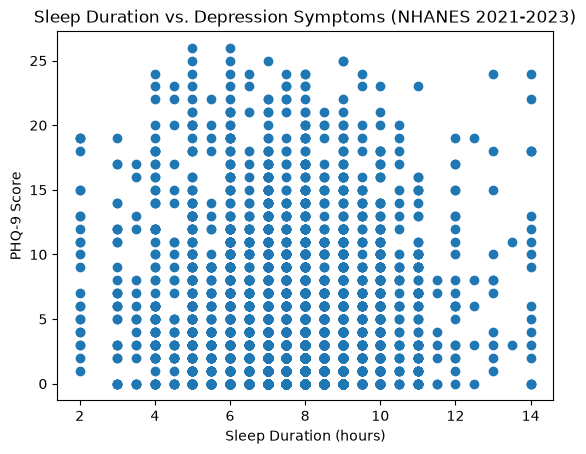

In [23]:
plt.scatter(df['SLD012'], df['phq9_score'])
plt.xlabel('Sleep Duration (hours)')
plt.ylabel('PHQ-9 Score')
plt.title('Sleep Duration vs. Depression Symptoms (NHANES 2021-2023)')
plt.show()

The scatter plot confirms what the correlation coefficient already told us — a cloud with no clear diagonal pattern.

A few observations:
- **Grid pattern:** Sleep duration is reported in 0.5-hour increments and PHQ-9 in whole numbers, so dots stack at discrete coordinates rather than spreading freely.
- **Bottom-heavy:** Most dots cluster at low PHQ-9 scores, consistent with the right-skewed distribution.
- **High scores at every sleep duration:** Respondents scoring 20+ (severe) appear at both 4 hours and 10+ hours of sleep. The cloud extends the full height of the chart regardless of sleep duration.

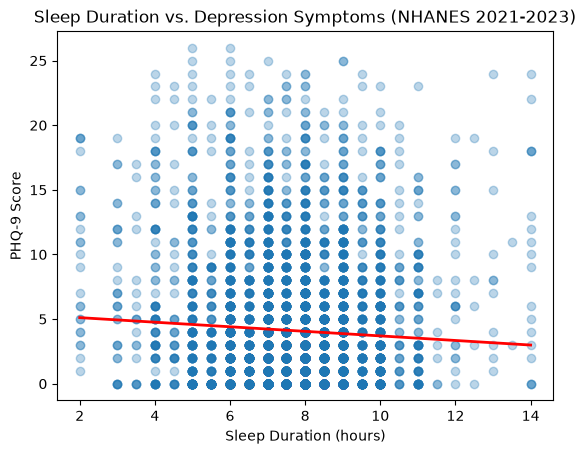

In [26]:
# Add the trend line to the scatter plot
# Fit a line to the data
m, b = np.polyfit(df['SLD012'], df['phq9_score'], 1)
trend = np.poly1d([m, b])
x_line = np.linspace(df['SLD012'].min(), df['SLD012'].max(), 100)

# Plot the scatter plot with the trend line
plt.scatter(df['SLD012'], df['phq9_score'], alpha=0.3)
plt.plot(x_line, trend(x_line), color='red', linewidth=2)
plt.xlabel('Sleep Duration (hours)')
plt.ylabel('PHQ-9 Score')
plt.title('Sleep Duration vs. Depression Symptoms (NHANES 2021-2023)')
plt.savefig(r"C:\Users\brigi\source\repos\brigitschroeder\public\images\001-sleep-scatter.png", dpi=150, bbox_inches='tight')
plt.show()

The trend line drops from roughly PHQ-9=5 at 2 hours of sleep to PHQ-9=3 at 14 hours — a 2-point change across a 12-hour range on a 27-point scale. Nearly flat.

### Summary

- There is a statistically significant but negligible negative correlation between sleep duration and depression symptoms (Spearman r = −0.043, p = 0.0016)
- Longer sleep is associated with slightly lower PHQ-9 scores, but sleep duration explains almost none of the variation in depression scores
- People with severe depression symptoms appear at every sleep duration